In [29]:
%pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [30]:
%pip install scikit-optimize

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [31]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from scikeras.wrappers import KerasClassifier

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [32]:
train = "../datasets/final_train.csv"
test = "../datasets/test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [33]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(np.unique(y_encoded))

print("Number of classes:", num_classes)

Number of classes: 4


In [34]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

Train shape: (154214, 118, 1)
Test shape: (52256, 118, 1)


In [35]:
early_stop = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

In [36]:
def build_cnn(filters=64,kernel_size=3,dense_units=128,dropout=0.5,lr=0.001):

    
    model = Sequential([

        Conv1D(filters,kernel_size,padding="same",activation="relu",input_shape=(X.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 2,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 4,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        GlobalAveragePooling1D(),

        Dense(dense_units, activation="relu"),

        Dropout(dropout),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
   

In [37]:
cnn_model = KerasClassifier(
    model=build_cnn,
    verbose=0
)

In [38]:
search_spaces = {
    "model__filters": Integer(32, 128),
    "model__dense_units": Integer(64, 256),
    "model__dropout": Real(0.1, 0.5),
    "model__kernel_size": Integer(3, 7),
    "model__lr": Real(1e-5, 1e-2, prior="log-uniform"),
    "batch_size": Integer(16, 64)
}

In [39]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [40]:
bayes_search = BayesSearchCV(
    estimator=cnn_model,
    search_spaces=search_spaces,
    n_iter=5,
    cv=skf,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=10,
    random_state=42
)

bayes_search.fit(X, y_encoded, callbacks=[early_stop])

print("\nBest parameters:", bayes_search.best_params_)
print("Best CV score:", bayes_search.best_score_)

Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV 1/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 1/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=0.882 total time=  27.4s
[CV 2/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 2/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=0.885 total time=  26.6s
[CV 3/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


...

[CV 9/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.884 total time=  38.9s
[CV 10/10; 1/1] START batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 10/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.881 total time=  39.2s


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best parameters: OrderedDict({'batch_size': 36, 'model__dense_units': 204, 'model__dropout': 0.47314719953913353, 'model__filters': 62, 'model__kernel_size': 6, 'model__lr': 0.00017472534129202037})
Best CV score: 0.8829219299537785


In [41]:
best_params = bayes_search.best_params_

final_model = build_cnn(
    filters=best_params["model__filters"],
    kernel_size=best_params["model__kernel_size"],
    dense_units=best_params["model__dense_units"],
    dropout=best_params["model__dropout"],
    lr=best_params["model__lr"]
)

history = final_model.fit(
    X,
    y_encoded,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4820/4820 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - accuracy: 0.9118 - loss: 0.2247


In [42]:
predictions = final_model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(y_test_encoded, predicted_classes)
f1 = f1_score(y_test_encoded, predicted_classes, average="weighted")

print("\nTest Accuracy:", accuracy)
print("Test F1 Score:", f1)

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Test Accuracy: 0.9252334660134721
Test F1 Score: 0.9036385208556379


In [43]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        predicted_classes,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(y_test_encoded, predicted_classes)

print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))


Classification Report:
                      precision    recall  f1-score   support

   Credential Access       1.00      1.00      1.00      8699
           Discovery       0.78      1.00      0.87     13431
Resource Development       0.00      0.00      0.00      2723
                none       1.00      0.96      0.98     27403

            accuracy                           0.93     52256
           macro avg       0.69      0.74      0.71     52256
        weighted avg       0.89      0.93      0.90     52256


False Positive Rate (per class)
Credential Access: 0.0000
Discovery: 0.1001
Resource Development: 0.0000
none: 0.0009

Average FPR: 0.025237399126438475


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


<Figure size 1200x1200 with 0 Axes>

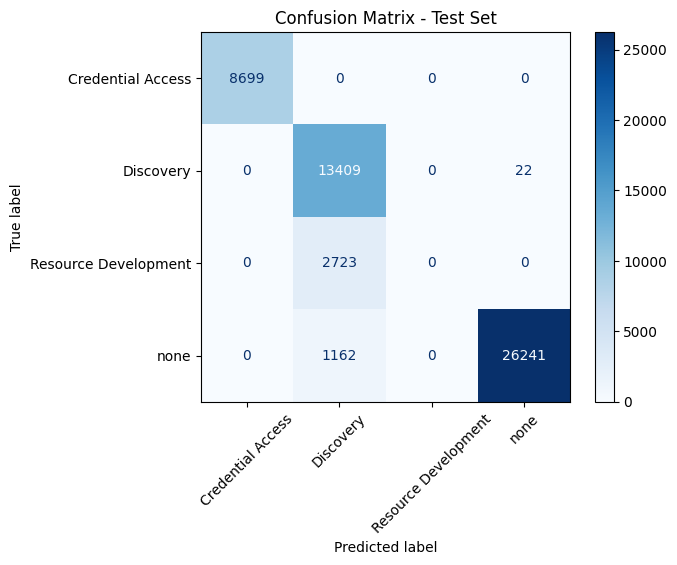

In [44]:
y_test_pred = np.argmax(final_model.predict(X_test), axis=1)
cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()